# Pooled rare variants → AnnData

A pooled rare-variant screen ([`cpg0032`](https://broadinstitute.github.io/cellpainting-gallery/)). Like PERISCOPE the unit is a barcode/gene rather than a well.

One observation is a well, one variable is a CellProfiler feature.
Well-level profiles only, no images:

```bash
aws s3 cp --no-sign-request --recursive --exclude "*" --include "*_gene_normalized_ALLBATCHES___ALLPLATES___ALLWELLS.csv.gz" \
  s3://cellpainting-gallery/cpg0032-pooled-rare/broad/workspace/profiles/ .
```

In [1]:
from __future__ import annotations

from pathlib import Path

import numpy as np
import scanpy as sc

import cell_painting_io as cpio

PROFILES = Path("~/data/cpg0032-pooled-rare/profiles").expanduser()

In [2]:
files = sorted(PROFILES.glob("*/*.csv.gz"))
print(f"{len(files)} plates")

1 plates


In [3]:
adata = cpio.read_profiles(files, on_column_mismatch="intersect")
adata

/home/lheumos/miniforge3/envs/cell-painting-io/lib/python3.14/functools.py:982: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


AnnData object with n_obs × n_vars = 290 × 4445
    obs: 'Foci_Barcode_MatchedTo_GeneCode'
    layers: None (.X)

In [4]:
cpio.annotate_features(adata.var)
adata = cpio.drop_incomplete_features(adata)
adata = cpio.drop_extreme_features(adata)
adata = cpio.drop_constant_features(adata)


def present(columns):
    return [c for c in columns if c in adata.obs.columns and adata.obs[c].nunique() > 1]


cpio.categorize(adata, present([]))
adata.var

,compartment,family,channel,channel_2,n_channels
feature,,,,,
Cells_AreaShape_Center_X_x,cells,areashape,NaN,NaN,0
Cells_AreaShape_Center_Y_x,cells,areashape,NaN,NaN,0
Cytoplasm_AreaShape_Center_X_x,cytoplasm,areashape,NaN,NaN,0
Cytoplasm_AreaShape_Center_Y_x,cytoplasm,areashape,NaN,NaN,0
Nuclei_AreaShape_Center_X_x,nuclei,areashape,NaN,NaN,0
...,...,...,...,...,...
Nuclei_Texture_Variance_WGA_10_03_256,nuclei,texture,NaN,NaN,0
Nuclei_Texture_Variance_WGA_5_00_256,nuclei,texture,NaN,NaN,0
Nuclei_Texture_Variance_WGA_5_01_256,nuclei,texture,NaN,NaN,0


## Sanity checks

In [5]:
print(f"{adata.n_obs:,} wells x {adata.n_vars:,} features")
print(f"non-finite: {int((~np.isfinite(adata.X)).sum())} | max|x|: {np.abs(adata.X).max():.1f}")
for column in present(["Foci_Barcode_MatchedTo_GeneCode"]):
    print(f"\n{column}:")
    print(adata.obs[column].value_counts(dropna=False).head(6).to_string())

290 wells x 4,046 features
non-finite: 0 | max|x|: 4237.5

Foci_Barcode_MatchedTo_GeneCode:
Foci_Barcode_MatchedTo_GeneCode
ACTB           1
ACTB E364K     1
ACTB R183W     1
ACTN4          1
ACTN4 K255E    1
ACVRL1         1


In [6]:
adata.write_h5ad(PROFILES.parent / "pooled_rare.h5ad")

## UMAP

Observations are barcodes rather than wells.

In [7]:
sc.pp.pca(adata, n_comps=min(50, adata.n_vars - 1))
sc.pp.neighbors(adata, n_neighbors=15)
sc.tl.umap(adata)

/home/lheumos/miniforge3/envs/cell-painting-io/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


How often do neighbouring wells share a label, against the rate expected if labels were shuffled?
Above 1 means the covariate explains part of the embedding.

In [8]:
cpio.neighbour_enrichment(adata, present(["Foci_Barcode_MatchedTo_GeneCode"]))

,observed,baseline,ratio
covariate,,,
Foci_Barcode_MatchedTo_GeneCode,0.0,0.003,0.0


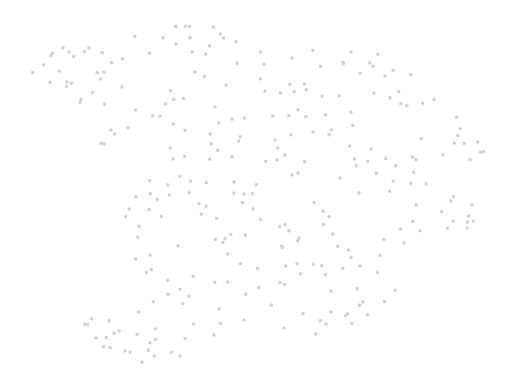

In [9]:
colours = present([])[:3] or None
crowded = bool(colours) and max(adata.obs[c].nunique() for c in colours) > 20
sc.pl.umap(adata, color=colours, ncols=3, frameon=False, size=25, legend_loc="none" if crowded else "right margin")